In [ ]:

# Population Exposure to Rising Temperatures

## Data Preprocessing and Feature Engineering

In [1]:

from pathlib import Path
import sys
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

# Find the repository root.

current_dir = Path.cwd().resolve()

project_root = next(
    (
        path
        for path in (current_dir, current_dir.parent)
        if (
            path / "data" / "raw" /
            "GlobalLandTemperaturesByCountry.csv"
        ).exists()
    ),
    None
)

if project_root is None:
    raise FileNotFoundError(
        "Cannot find the project data/raw folder."
    )

sys.path.insert(
    0,
    str(project_root / "code")
)

import preprocess as pp

print("Project root:", project_root)

Project root: C:\Users\navod\Desktop\ML\PRT565-Machine-Learning


In [ ]:

## 1. Raw Dataset Inspection

# Before cleaning the datasets, we examine their dimensions,
# column names, date coverage and missing values.

# This allows us to document the original data quality and
# justify the preprocessing decisions.

In [2]:

climate_df, population_df, raw_audit = (
    pp.load_and_audit(
        project_root / "data" / "raw"
    )
)

print("Climate shape:", climate_df.shape)
print("Population shape:", population_df.shape)

print("\nClimate preview:")
display(climate_df.head())

print("\nPopulation preview:")
display(population_df.head())

print("\nClimate missing values:")
display(climate_df.isna().sum())

print("\nPopulation missing values:")
display(population_df.isna().sum())

print("\nRaw data audit:")
display(pd.Series(raw_audit))

Climate shape: (577462, 4)
Population shape: (234, 17)

Climate preview:


,dt,AverageTemperature,AverageTemperatureUncertainty,Country
0,1743-11-01,4.384,2.294,Åland
1,1743-12-01,NaN,NaN,Åland
2,1744-01-01,NaN,NaN,Åland
3,1744-02-01,NaN,NaN,Åland
4,1744-03-01,NaN,NaN,Åland



Population preview:


,Rank,CCA3,Country/Territory,Capital,Continent,2022 Population,2020 Population,2015 Population,2010 Population,2000 Population,1990 Population,1980 Population,1970 Population,Area (km²),Density (per km²),Growth Rate,World Population Percentage
0,36,AFG,Afghanistan,Kabul,Asia,41128771,38972230,33753499,28189672,19542982,10694796,12486631,10752971,652230,63.0587,1.0257,0.52
1,138,ALB,Albania,Tirana,Europe,2842321,2866849,2882481,2913399,3182021,3295066,2941651,2324731,28748,98.8702,0.9957,0.04
2,34,DZA,Algeria,Algiers,Africa,44903225,43451666,39543154,35856344,30774621,25518074,18739378,13795915,2381741,18.8531,1.0164,0.56
3,213,ASM,American Samoa,Pago Pago,Oceania,44273,46189,51368,54849,58230,47818,32886,27075,199,222.4774,0.9831,0.00
4,203,AND,Andorra,Andorra la Vella,Europe,79824,77700,71746,71519,66097,53569,35611,19860,468,170.5641,1.0100,0.00



Climate missing values:


dt                                   0
AverageTemperature               32651
AverageTemperatureUncertainty    31912
Country                              0
dtype: int64


Population missing values:


Rank                           0
CCA3                           0
Country/Territory              0
Capital                        0
Continent                      0
2022 Population                0
2020 Population                0
2015 Population                0
2010 Population                0
2000 Population                0
1990 Population                0
1980 Population                0
1970 Population                0
Area (km²)                     0
Density (per km²)              0
Growth Rate                    0
World Population Percentage    0
dtype: int64


Raw data audit:


climate_rows                                                            577462
population_rows                                                            234
climate_countries                                                          243
population_countries                                                       234
missing_climate_values       {'dt': 0, 'AverageTemperature': 32651, 'Averag...
missing_population_values    {'Rank': 0, 'CCA3': 0, 'Country/Territory': 0,...
climate_start_date                                                  1743-11-01
climate_end_date                                                    2013-09-01
dtype: object

In [ ]:

## 2. Country-Name Standardization

# The datasets use different naming conventions for some
# countries and territories.

# Country names are normalized, and explicitly reviewed
# aliases are applied.

# Unmatched countries are retained in a matching-audit table
# rather than silently discarded.

In [3]:

importlib.reload(pp)

matched_countries, country_audit = (
    pp.make_country_crosswalk(
        climate_df,
        population_df
    )
)

print(
    "Matched locations:",
    matched_countries["cca3"].nunique()
)

print("\nMatching methods:")
display(
    country_audit["matching_method"]
    .value_counts()
)

print("\nUnmatched locations:")
display(
    country_audit.loc[
        country_audit["population_country"].isna(),
        ["climate_country", "matching_method"]
    ]
)

print("\nSample country crosswalk:")
display(matched_countries.head(10))

Matched locations: 221

Matching methods:


matching_method
exact           198
unmatched        22
normalized       12
manual_alias     11
Name: count, dtype: int64


Unmatched locations:


,climate_country,matching_method
0,Åland,unmatched
2,Africa,unmatched
9,Antarctica,unmatched
14,Asia,unmatched
20,Baker Island,unmatched
29,"Bonaire, Saint Eustatius And Saba",unmatched
48,Christmas Island,unmatched
59,Denmark (Europe),unmatched
71,Europe,unmatched
77,France (Europe),unmatched



Sample country crosswalk:


,climate_country,normalized_name,join_key,cca3,population_country,matching_method
1,Afghanistan,afghanistan,afghanistan,AFG,Afghanistan,exact
3,Albania,albania,albania,ALB,Albania,exact
4,Algeria,algeria,algeria,DZA,Algeria,exact
5,American Samoa,american samoa,american samoa,ASM,American Samoa,exact
6,Andorra,andorra,andorra,AND,Andorra,exact
7,Angola,angola,angola,AGO,Angola,exact
8,Anguilla,anguilla,anguilla,AIA,Anguilla,exact
10,Antigua And Barbuda,antigua and barbuda,antigua and barbuda,ATG,Antigua and Barbuda,normalized
11,Argentina,argentina,argentina,ARG,Argentina,exact
12,Armenia,armenia,armenia,ARM,Armenia,exact


In [ ]:

## 3. Annual Temperature Aggregation

# Monthly temperatures are aggregated into annual mean
# temperatures for the period 1960–2009.

# Only country-years with 12 valid monthly observations
# are retained. Incomplete country-years are recorded
# separately for data-quality reporting.

Complete country-years: 11050
Incomplete country-years: 0


,cca3,year,annual_mean_temp_c,valid_months,annual_mean_uncertainty_c
0,ABW,1960,28.253583,12,0.453083
1,ABW,1961,28.072833,12,0.370083
2,ABW,1962,28.286000,12,0.331333
3,ABW,1963,28.317250,12,0.318583
4,ABW,1964,28.076417,12,0.301167
5,ABW,1965,28.046750,12,0.393167
6,ABW,1966,28.241167,12,0.334250
7,ABW,1967,27.954750,12,0.400250
8,ABW,1968,28.114333,12,0.320083
9,ABW,1969,28.631000,12,0.365667


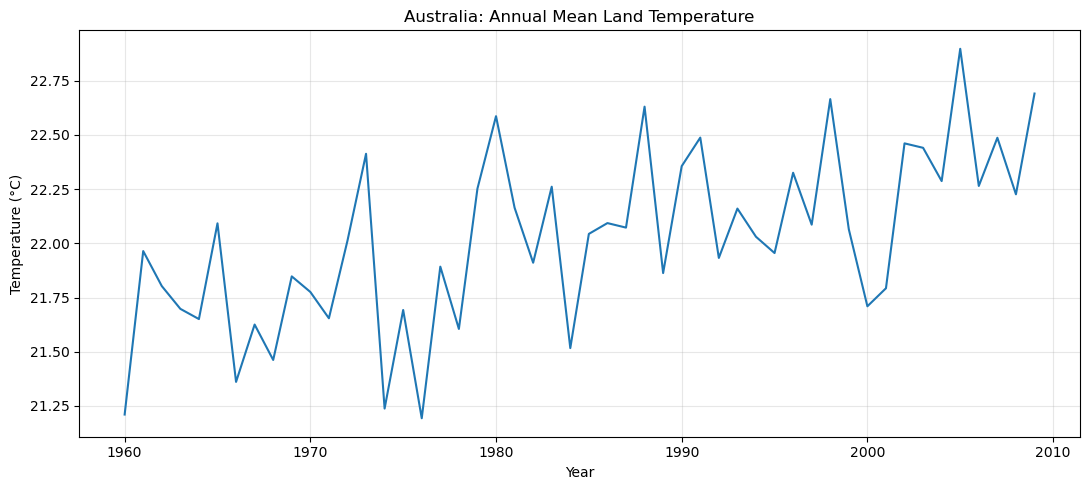

In [4]:

importlib.reload(pp)

annual_climate, incomplete_years = (
    pp.annual_climate_table(
        climate_df,
        matched_countries
    )
)

print(
    "Complete country-years:",
    len(annual_climate)
)

print(
    "Incomplete country-years:",
    len(incomplete_years)
)

display(annual_climate.head(10))

# Examine Australia's annual temperature series.

australia_annual = annual_climate[
    annual_climate["cca3"] == "AUS"
].copy()

plt.figure(figsize=(11, 5))

plt.plot(
    australia_annual["year"],
    australia_annual["annual_mean_temp_c"]
)

plt.title("Australia: Annual Mean Land Temperature")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:

## 4. Historical Climate Feature Engineering

# For each complete ten-year period, a linear regression
# slope is calculated to estimate the change in average
# land temperature in degrees Celsius per decade.

# Temperature volatility is calculated using the standard
# deviation of the residuals around the fitted trend.

# Detrending separates year-to-year variability from
# the overall warming or cooling trend.

In [5]:

importlib.reload(pp)

decadal_climate = pp.compute_decadal_climate(
    annual_climate
)

print(
    "Complete country-decade records:",
    len(decadal_climate)
)

display(decadal_climate.head())

print("\nAustralia's historical climate features:")

display(
    decadal_climate[
        decadal_climate["cca3"] == "AUS"
    ]
)

print("\nDescriptive statistics:")

display(
    decadal_climate[
        [
            "warming_c_per_decade",
            "detrended_volatility_c",
            "mean_uncertainty_c",
        ]
    ].describe()
)

Complete country-decade records: 1105


,cca3,decade_start,decade_end,mean_temp_c,warming_c_per_decade,detrended_volatility_c,mean_uncertainty_c
0,ABW,1960,1969,28.199408,0.107460,0.189841,0.358767
1,ABW,1970,1979,28.167542,0.197955,0.287829,0.327217
2,ABW,1980,1989,28.342575,-0.270318,0.302661,0.324258
3,ABW,1990,1999,28.531633,0.322152,0.224315,0.317167
4,ABW,2000,2009,28.664583,0.307303,0.219818,0.341200



Australia's historical climate features:


,cca3,decade_start,decade_end,mean_temp_c,warming_c_per_decade,detrended_volatility_c,mean_uncertainty_c
55,AUS,1960,1969,21.671450,0.046212,0.271847,0.211875
56,AUS,1970,1979,21.772908,0.008712,0.391746,0.196958
57,AUS,1980,1989,22.114075,-0.146389,0.327260,0.184042
58,AUS,1990,1999,22.206200,-0.011626,0.242982,0.180300
59,AUS,2000,2009,22.325500,0.731646,0.289404,0.176900



Descriptive statistics:


,warming_c_per_decade,detrended_volatility_c,mean_uncertainty_c
count,1105.000000,1105.000000,1105.000000
mean,0.135623,0.329776,0.336008
std,0.430989,0.180512,0.117833
min,-1.821828,0.076268,0.157867
25%,-0.092268,0.206819,0.259033
50%,0.135308,0.272078,0.306925
75%,0.352141,0.406712,0.370317
max,2.418732,1.187297,0.929767


In [ ]:

## 5. Historical Population Feature Engineering

# The population dataset contains historical population
# snapshots in separate columns.

# These columns are transformed into country-year records.

# Historical population density is calculated using each
# year's population and the published land area. Growth
# over the previous decade is also calculated.

# Because the dataset does not include 1960 population,
# the previous-decade growth feature is missing for 1970.
# These missing values are preserved rather than invented.

In [6]:

importlib.reload(pp)

population_panel = (
    pp.historical_population_panel(
        population_df
    )
)

print(
    "Historical population observations:",
    len(population_panel)
)

display(population_panel.head(10))

print("\nAustralia's population history:")

display(
    population_panel[
        population_panel["cca3"] == "AUS"
    ]
)

print("\nMissing growth observations:")

print(
    population_panel[
        "growth_prior_decade_pct"
    ].isna().sum()
)

Historical population observations: 1170


,cca3,country,continent,area_km2,population_year,population,density_per_km2,growth_prior_decade_pct
0,ABW,Aruba,North America,180,1970,59106,328.366667,NaN
1,ABW,Aruba,North America,180,1980,62267,345.927778,5.348019
2,ABW,Aruba,North America,180,1990,65712,365.066667,5.532626
3,ABW,Aruba,North America,180,2000,89101,495.005556,35.593195
4,ABW,Aruba,North America,180,2010,100341,557.450000,12.614898
5,AFG,Afghanistan,Asia,652230,1970,10752971,16.486471,NaN
6,AFG,Afghanistan,Asia,652230,1980,12486631,19.144521,16.122614
7,AFG,Afghanistan,Asia,652230,1990,10694796,16.397277,-14.350028
8,AFG,Afghanistan,Asia,652230,2000,19542982,29.963329,82.733565
9,AFG,Afghanistan,Asia,652230,2010,28189672,43.220447,44.244476



Australia's population history:


,cca3,country,continent,area_km2,population_year,population,density_per_km2,growth_prior_decade_pct
55,AUS,Australia,Oceania,7692024,1970,12595034,1.637415,NaN
56,AUS,Australia,Oceania,7692024,1980,14706322,1.911892,16.762861
57,AUS,Australia,Oceania,7692024,1990,17048003,2.216322,15.922955
58,AUS,Australia,Oceania,7692024,2000,19017963,2.472426,11.555371
59,AUS,Australia,Oceania,7692024,2010,22019168,2.862597,15.780896



Missing growth observations:
234


In [ ]:

## 6. Country-Period Integration

# The engineered climate and population features are
# combined using country codes and historical periods.

# For each reference year, predictors include the previous
# decade's temperature characteristics and population
# information at that reference year.

# Subsequent warming and population density are retained
# only for constructing the classification outcome.
# They must not be passed directly to the ML models.

In [7]:

importlib.reload(pp)

country_periods = pp.build_country_periods(
    decadal_climate,
    population_panel
)

print(
    "Country-period observations:",
    len(country_periods)
)

print("\nObservations by reference year:")

display(
    country_periods.groupby(
        "reference_year"
    ).size()
)

print("\nAustralia's country-period records:")

display(
    country_periods[
        country_periods["cca3"] == "AUS"
    ]
)

assert not country_periods.duplicated(
    ["cca3", "reference_year"]
).any()

Country-period observations: 884

Observations by reference year:


reference_year
1970    221
1980    221
1990    221
2000    221
dtype: int64


Australia's country-period records:


,cca3,country,continent,area_km2,reference_year,population_at_reference,density_at_reference_per_km2,population_growth_prior_decade_pct,prior_decade_start,prior_decade_mean_temp_c,prior_decade_warming_c_per_decade,prior_decade_detrended_volatility_c,prior_decade_mean_temp_uncertainty_c,future_warming_c_per_decade,outcome_population_year,outcome_population,future_density_per_km2
44,AUS,Australia,Oceania,7692024,1970,12595034,1.637415,NaN,1960,21.671450,0.046212,0.271847,0.211875,0.008712,1980,14706322,1.911892
45,AUS,Australia,Oceania,7692024,1980,14706322,1.911892,16.762861,1970,21.772908,0.008712,0.391746,0.196958,-0.146389,1990,17048003,2.216322
46,AUS,Australia,Oceania,7692024,1990,17048003,2.216322,15.922955,1980,22.114075,-0.146389,0.327260,0.184042,-0.011626,2000,19017963,2.472426
47,AUS,Australia,Oceania,7692024,2000,19017963,2.472426,11.555371,1990,22.206200,-0.011626,0.242982,0.180300,0.731646,2010,22019168,2.862597


In [ ]:

## 7. Classification Target and Temporal Split

# The exposure category is a constructed index combining
# subsequent warming and subsequent population density.

# Each component is converted into a percentile relative
# to the historical training observations. The geometric
# mean combines the two components.

# The training period uses reference years 1970, 1980 and
# 1990. The reference year 2000 is reserved for temporal
# testing.

# Training data alone establish the percentile reference
# distributions and Low/Medium/High class boundaries.

# Future outcome variables and exposure scores must not
# be used as predictive features.

In [8]:

importlib.reload(pp)

train_df, test_df, label_metadata = (
    pp.create_exposure_labels(
        country_periods
    )
)

print("Training observations:", len(train_df))
print("Testing observations:", len(test_df))

print("\nTraining class distribution:")

display(
    train_df[
        "target_exposure_class"
    ].value_counts()
)

print("\nTesting class distribution:")

display(
    test_df[
        "target_exposure_class"
    ].value_counts()
)

print("\nLabel definitions:")

display(pd.Series(label_metadata))

Training observations: 663
Testing observations: 221

Training class distribution:


target_exposure_class
Low       221
Medium    221
High      221
Name: count, dtype: int64


Testing class distribution:


target_exposure_class
Medium    95
High      65
Low       61
Name: count, dtype: int64


Label definitions:


target                Constructed subsequent warming-density exposur...
train_years                                          [1970, 1980, 1990]
test_year                                                          2000
low_medium_cutoff                                              0.317102
medium_high_cutoff                                              0.56161
predictors            [population_at_reference, density_at_reference...
class_order                                         [Low, Medium, High]
dtype: object

In [ ]:

# Confirm that the test period was not
# used as part of the training period.

assert train_df["reference_year"].max() < 2000

assert (
    test_df["reference_year"] == 2000
).all()

print("Temporal split validation passed.")

In [ ]:

## 8. Final Data Quality Review and Export

# The final stage exports the cleaned intermediate datasets,
# the country-matching audit, the model-ready training and
# testing data, and the classification methodology.

# Only the predefined historical predictor features are
# included in the model-ready files.

# The full audit dataset is saved separately and must not
# be used as the ML feature matrix.

In [9]:

importlib.reload(pp)

results = pp.run_pipeline(
    project_root
)

train_model = results["train"]
test_model = results["test"]

print("\nFinal training data:")
display(train_model.head())

print("\nFinal testing data:")
display(test_model.head())

print("\nTraining data information:")
train_model.info()

Preprocessing completed successfully.
Model-ready files saved to: C:\Users\navod\Desktop\ML\PRT565-Machine-Learning\data\processed

Final training data:


,country,cca3,reference_year,population_at_reference,density_at_reference_per_km2,population_growth_prior_decade_pct,prior_decade_mean_temp_c,prior_decade_warming_c_per_decade,prior_decade_detrended_volatility_c,prior_decade_mean_temp_uncertainty_c,area_km2,continent,target_exposure_class
0,Aruba,ABW,1970,59106,328.366667,NaN,28.199408,0.107460,0.189841,0.358767,180,North America,High
1,Aruba,ABW,1980,62267,345.927778,5.348019,28.167542,0.197955,0.287829,0.327217,180,North America,Low
2,Aruba,ABW,1990,65712,365.066667,5.532626,28.342575,-0.270318,0.302661,0.324258,180,North America,High
4,Afghanistan,AFG,1970,10752971,16.486471,NaN,13.961283,-0.322576,0.494226,0.411983,652230,Asia,Low
5,Afghanistan,AFG,1980,12486631,19.144521,16.122614,14.035983,0.108848,0.746613,0.412525,652230,Asia,Low



Final testing data:


,country,cca3,reference_year,population_at_reference,density_at_reference_per_km2,population_growth_prior_decade_pct,prior_decade_mean_temp_c,prior_decade_warming_c_per_decade,prior_decade_detrended_volatility_c,prior_decade_mean_temp_uncertainty_c,area_km2,continent,target_exposure_class
3,Aruba,ABW,2000,89101,495.005556,35.593195,28.531633,0.322152,0.224315,0.317167,180,North America,High
7,Afghanistan,AFG,2000,19542982,29.963329,82.733565,14.732458,0.799712,0.324100,0.451775,652230,Asia,Low
11,Angola,AGO,2000,16394062,13.149966,38.596362,22.477567,0.413253,0.294703,0.494600,1246700,Africa,Low
15,Anguilla,AIA,2000,11047,121.395604,32.840308,27.266525,0.514823,0.175331,0.282558,91,North America,High
19,Albania,ALB,2000,3182021,110.686691,-3.430736,13.149892,0.307763,0.498491,0.328900,28748,Europe,Medium



Training data information:
<class 'pandas.core.frame.DataFrame'>
Index: 663 entries, 0 to 882
Data columns (total 13 columns):
 #   Column                                Non-Null Count  Dtype   
---  ------                                --------------  -----   
 0   country                               663 non-null    object  
 1   cca3                                  663 non-null    object  
 2   reference_year                        663 non-null    int64   
 3   population_at_reference               663 non-null    int64   
 4   density_at_reference_per_km2          663 non-null    float64 
 5   population_growth_prior_decade_pct    442 non-null    float64 
 6   prior_decade_mean_temp_c              663 non-null    float64 
 7   prior_decade_warming_c_per_decade     663 non-null    float64 
 8   prior_decade_detrended_volatility_c   663 non-null    float64 
 9   prior_decade_mean_temp_uncertainty_c  663 non-null    float64 
 10  area_km2                              663 non-null 

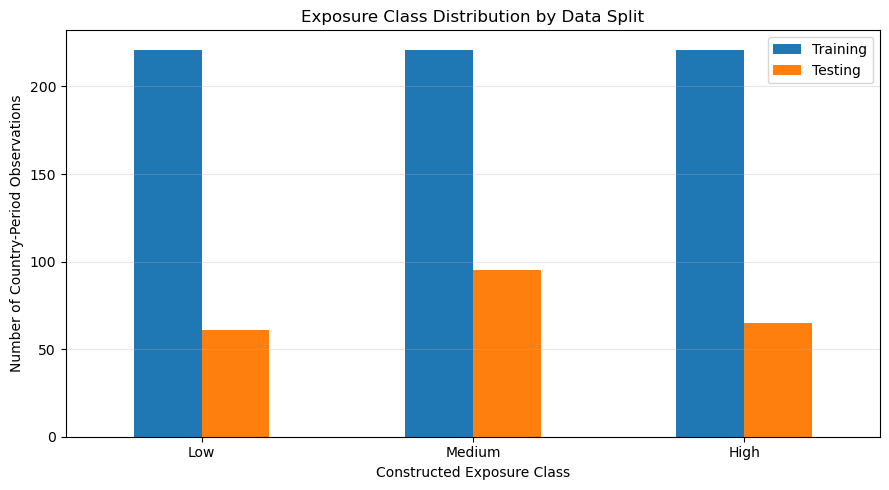

In [10]:

train_counts = (
    train_model["target_exposure_class"]
    .value_counts()
    .reindex(["Low", "Medium", "High"])
)

test_counts = (
    test_model["target_exposure_class"]
    .value_counts()
    .reindex(["Low", "Medium", "High"])
)

class_distribution = pd.DataFrame({
    "Training": train_counts,
    "Testing": test_counts,
})

ax = class_distribution.plot(
    kind="bar",
    figsize=(9, 5),
    rot=0
)

ax.set_title(
    "Exposure Class Distribution by Data Split"
)

ax.set_xlabel(
    "Constructed Exposure Class"
)

ax.set_ylabel(
    "Number of Country-Period Observations"
)

ax.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

figures_dir = (
    project_root / "outputs" / "figures"
)

figures_dir.mkdir(
    parents=True,
    exist_ok=True
)

plt.savefig(
    figures_dir / "exposure_class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [11]:

forbidden_features = {
    "future_warming_c_per_decade",
    "future_density_per_km2",
    "outcome_population",
    "future_exposure_index",
}

assert forbidden_features.isdisjoint(
    train_model.columns
)

assert forbidden_features.isdisjoint(
    test_model.columns
)

assert not train_model.duplicated(
    ["cca3", "reference_year"]
).any()

assert not test_model.duplicated(
    ["cca3", "reference_year"]
).any()

assert set(
    train_model["target_exposure_class"].dropna()
).issubset(
    {"Low", "Medium", "High"}
)

assert set(
    test_model["target_exposure_class"].dropna()
).issubset(
    {"Low", "Medium", "High"}
)

print("Final data-quality checks passed.")

Final data-quality checks passed.
